**Title Name- Food Order Preference Clustering**

Install & Import Libraries
Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px


Load / Create Dataset


In [2]:
data = {
    'Cuisine': ['North Indian', 'South Indian', 'Chinese', 'North Indian', 'Healthy', 'Chinese', 'North Indian', 'Healthy'],
    'Order_Frequency': [15, 8, 12, 20, 5, 18, 10, 7],
    'Avg_Order_Value': [450, 320, 380, 520, 280, 410, 390, 300],
    'Dietary_Pref': ['Non-Veg', 'Veg', 'Non-Veg', 'Non-Veg', 'Veg', 'Non-Veg', 'Veg', 'Veg'],
    'Time_Of_Order': ['Dinner', 'Lunch', 'Dinner', 'Dinner', 'Lunch', 'Night', 'Lunch', 'Breakfast']
}

df = pd.DataFrame(data)
print("Dataset Loaded:")
df.head()

Dataset Loaded:


,Cuisine,Order_Frequency,Avg_Order_Value,Dietary_Pref,Time_Of_Order
0,North Indian,15,450,Non-Veg,Dinner
1,South Indian,8,320,Veg,Lunch
2,Chinese,12,380,Non-Veg,Dinner
3,North Indian,20,520,Non-Veg,Dinner
4,Healthy,5,280,Veg,Lunch


Data Preprocessing


In [5]:
categorical_cols = ['Cuisine', 'Dietary_Pref', 'Time_Of_Order']
numerical_cols = ['Order_Frequency', 'Avg_Order_Value']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

X = preprocessor.fit_transform(df)
print("Preprocessing Completed. Shape:", X.shape)

Preprocessing Completed. Shape: (8, 9)


PCA (Dimensionality Reduction)

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.75054606 0.10391201]
Total Variance Explained: 0.8544580626542939


Elbow Method + Find Optimal K

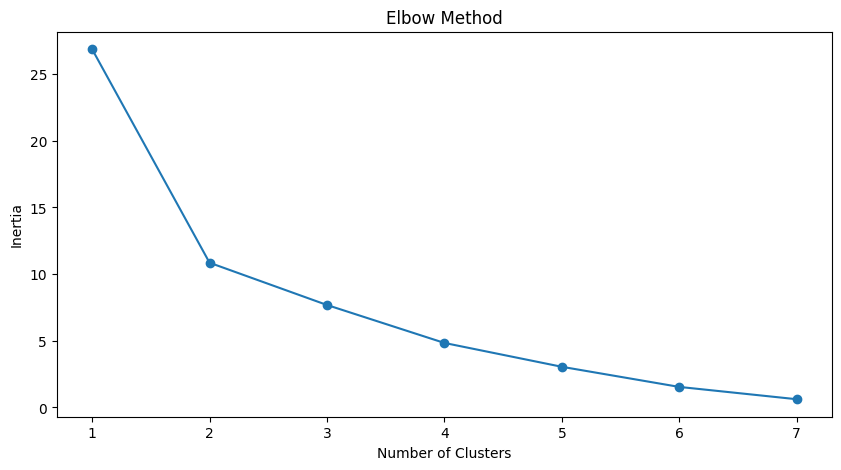

In [7]:
inertia = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Apply K-Means Clustering


In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

print("Clustering Done!")
df.head()

Clustering Done!


,Cuisine,Order_Frequency,Avg_Order_Value,Dietary_Pref,Time_Of_Order,Cluster
0,North Indian,15,450,Non-Veg,Dinner,0
1,South Indian,8,320,Veg,Lunch,3
2,Chinese,12,380,Non-Veg,Dinner,2
3,North Indian,20,520,Non-Veg,Dinner,0
4,Healthy,5,280,Veg,Lunch,1


Silhouette Score


In [9]:
sil_score = silhouette_score(X, df['Cluster'])
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.2369


Visualization

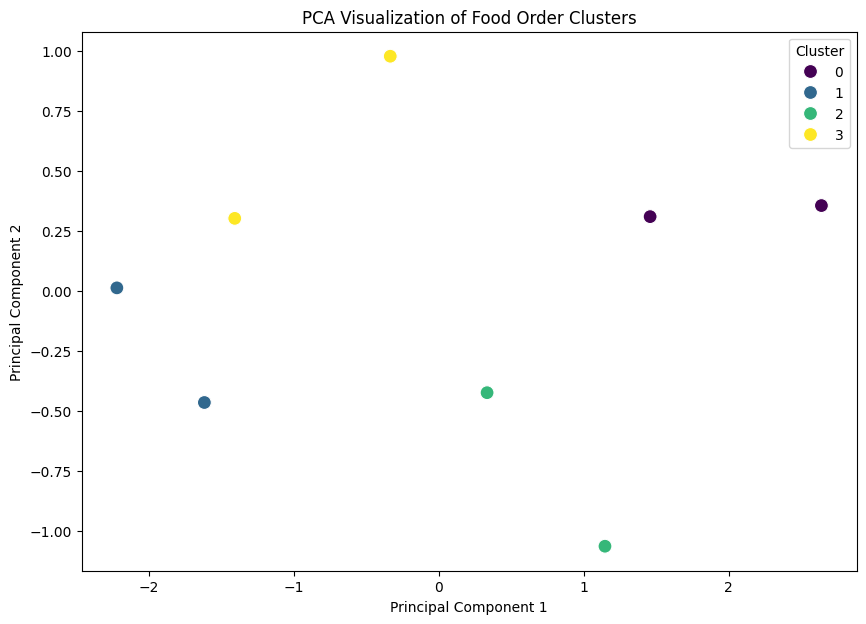

In [10]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='viridis', s=100)
plt.title('PCA Visualization of Food Order Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

Cluster Analysis

In [11]:
print("Cluster Analysis:")
print(df.groupby('Cluster').mean(numeric_only=True))
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

Cluster Analysis:
         Order_Frequency  Avg_Order_Value
Cluster                                  
0                   17.5            485.0
1                    6.0            290.0
2                   15.0            395.0
3                    9.0            355.0

Cluster Distribution:
Cluster
0    2
3    2
2    2
1    2
Name: count, dtype: int64
